<a href="https://colab.research.google.com/github/meghanavanamala/predictiveanalysis/blob/customer_movement_Randomforest/customer_movement_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Report:
              precision    recall  f1-score   support

           0       0.16      0.23      0.19        31
           1       0.25      0.28      0.26        40
           2       0.15      0.21      0.17        34
           3       0.23      0.15      0.18        47
           4       0.24      0.19      0.21        48

    accuracy                           0.20       200
   macro avg       0.21      0.21      0.20       200
weighted avg       0.21      0.20      0.21       200



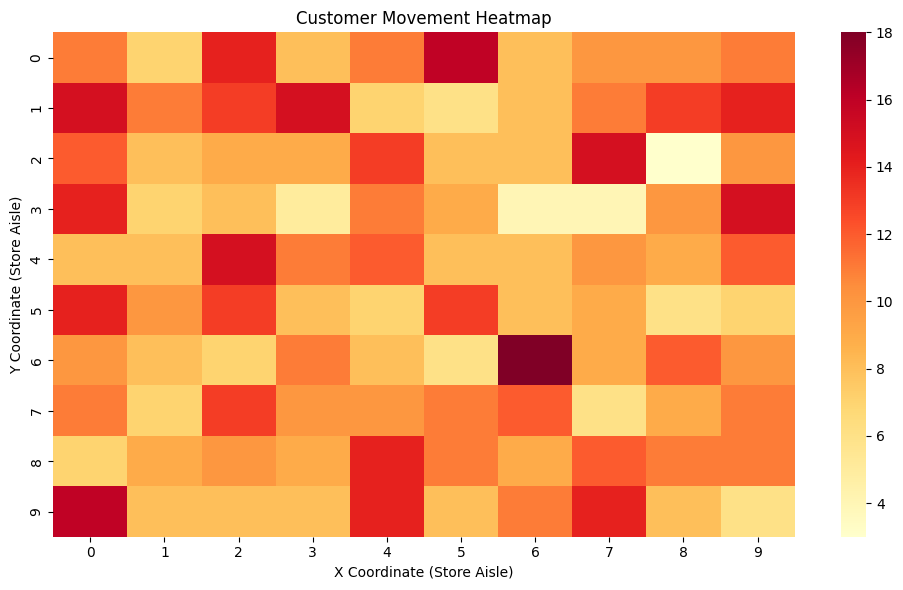

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate customer movement data
np.random.seed(42)
n_samples = 1000

df = pd.DataFrame({
    'x': np.random.randint(0, 10, n_samples),
    'y': np.random.randint(0, 10, n_samples),
    'time_of_day': np.random.choice(['Morning', 'Afternoon', 'Evening'], n_samples),
    'prev_section': np.random.choice(['Fruits', 'Dairy', 'Bakery', 'Snacks', 'Beverages'], n_samples),
    'basket_size': np.random.randint(0, 20, n_samples),
    'next_section': np.random.choice(['Fruits', 'Dairy', 'Bakery', 'Snacks', 'Beverages'], n_samples)
})

# Encode features
X = df[['x', 'y', 'time_of_day', 'prev_section', 'basket_size']]
X = pd.get_dummies(X)
y = df['next_section'].astype('category').cat.codes

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Create and save movement heatmap
heatmap_data = df.pivot_table(index='y', columns='x', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="YlOrRd")
plt.title("Customer Movement Heatmap")
plt.xlabel("X Coordinate (Store Aisle)")
plt.ylabel("Y Coordinate (Store Aisle)")
plt.tight_layout()
plt.savefig("customer_heatmap.png")
plt.show()
